In [1]:
pip install moviepy librosa openai-whisper matplotlib numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from moviepy import VideoFileClip
import whisper
import librosa
import librosa.display
import matplotlib.pyplot as plt

def analyze_interview_video(video_path):
    audio_path = "test_whisper.wav"
    
    # 1. 영상에서 오디오 추출 (안전한 방식)
    with VideoFileClip(video_path) as clip:
        if clip.audio is None:
            print("❌ 에러: 영상에 오디오 트랙이 없습니다. 다른 영상을 사용해주세요.")
            return
        
        # 오디오가 있을 때만 파일로 저장
        clip.audio.write_audiofile(audio_path, codec='pcm_s16le')

    # 2. Whisper 모델로 텍스트 추출
    model = whisper.load_model("base")
    result = model.transcribe(audio_path)
    
    # 3. 시각화
    y, sr = librosa.load(audio_path)
    plt.figure(figsize=(12, 4))
    librosa.display.waveshow(y, sr=sr)
    plt.title("Detected Audio Waveform")
    plt.show()

    print("--- 분석 완료 ---")
    print(f"추출된 텍스트: {result['text']}")

MoviePy - Writing audio in test_whisper.wav


MoviePy - Done.


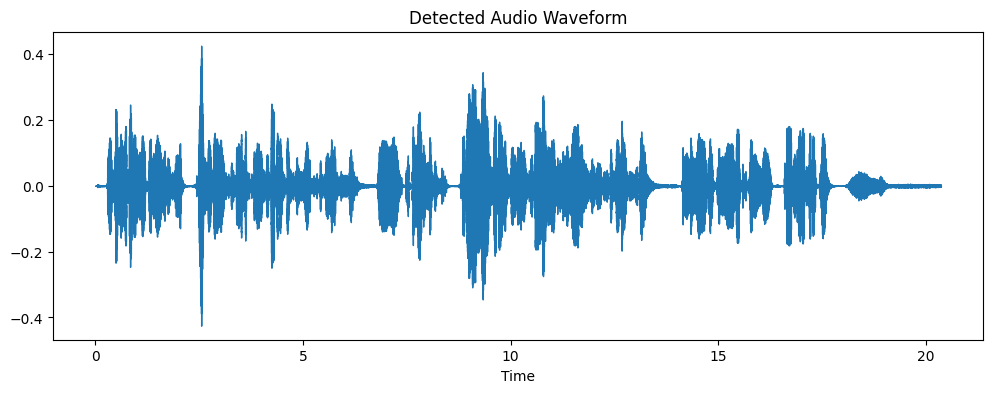

--- 분석 완료 ---
추출된 텍스트:  살면서 가장 힘들었던 경우에 뭔가요? 대학시절 틴프루젝트로 협업을 했던 경험이 가장 힘들었습니다. 아 어떤 점이 힘들던가요? 코로나로 오든속통을 비대면으로 진행을 해야 하는 점이 가장 힘들었습니다. 아니 우리에서 원격 근무가 기본인데 그 알고지원하신 거 맞죠? 아...


In [3]:
video = r"C:\Users\user\Downloads\bad_test.mp4"
analyze_interview_video(video)

In [ ]:
# 분당 단어 수 기반으로 말 속도 측정 방식. -> 문장 단어수 / 문장 시작부터 끝까지의 시간 

def analyze_speech_rate(video_path):
    audio_path = "test_whisper.wav"

    # Whisper 분석
    model = whisper.load_model("base")
    result = model.transcribe(audio_path)
    
    total_chars = 0
    total_speaking_time = 0
    
    print(f"\n{'내용':<50} | {'길이(초)':<15} | {'속도(글자/초)'}")
    print("-" * 60)

    for seg in result['segments']:
        text = seg['text'].strip()
        duration = seg['end'] - seg['start']
        
        if duration > 0:
            char_count = len(text.replace(" ", "")) # 공백 제외 글자 수
            cps = char_count / duration
            
            total_chars += char_count
            total_speaking_time += duration
            
            print(f"{text[:-1]:<30} | {duration:>8.2f} | {cps:>12.2f}")

    # 3. 최종 결과 출력
    if total_speaking_time > 0:

        # 분당 단어 수 구하는 부분. 제미나이 피셜 한국어 기준 초당 5~7글자가 적당하다고 함.
        avg_cps = total_chars / total_speaking_time
    
        print("\n" + "="*40)
        print(f"▶ 총 글자 수: {total_chars}자")
        print(f"▶ 실제 발화 시간: {total_speaking_time:.2f}초")
        print(f"▶ 평균 말하기 속도: {avg_cps:.2f} 글자/초")
        
        if avg_cps > 8: status = "매우 빠름 (전달력 저하 우려)"
        elif avg_cps < 4: status = "느림 (지루함 유발 우려)"
        else: status = "적절함 (안정적인 속도)"
        print(f"▶ 종합 판정: {status}")
        print("="*40)

In [9]:
video_path = r"C:\Users\user\Downloads\bad_test.mp4"
analyze_speech_rate(video_path)


내용                                                 | 길이(초)           | 속도(글자/초)
------------------------------------------------------------
살면서 가장 힘들었던 경우에 뭔가요            |     2.30 |         6.96
대학시절 틴프루젝트로 협업을 했던 경험이 가장 힘들었습니다 |     4.26 |         6.34
아 어떤 점이 힘들던가요                  |     2.08 |         5.29
코로나로 오든속통을 비대면으로 진행을 해야 하는 점이 가장 힘들었습니다 |     5.08 |         6.30
아니 우리에서 원격 근무가 기본인데 그 알고지원하신 거 맞죠 |     4.24 |         6.13
아..                            |     1.60 |         2.50

▶ 총 글자 수: 116자
▶ 실제 발화 시간: 19.56초
▶ 평균 말하기 속도: 5.93 글자/초
▶ 종합 판정: 적절함 (안정적인 속도)
